# Batch Stimulus Visualizer

This notebook loads multiple `*_trajectory.csv` files at once, computes angular position from `x/y`, and plots:
1. Facet view per file (angle + radius).
2. Grouped overlay by stimulus type (median + optional IQR band).
3. Polar summary (final or unique angular positions).

It is intentionally separate from `plots_stimuli.ipynb`.

In [1]:
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'src' / 'stimuli_timeline.py').exists():
        import sys
        sys.path.insert(0, str(candidate))
        break

from src.stimuli_timeline import get_angles_from_positions

pd.set_option('display.max_columns', 200)
plt.style.use('seaborn-v0_8-whitegrid')


In [2]:
# -----------------------------
# User config (quick reruns)
# -----------------------------
input_dir = Path('D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\stimuli\Exp_7_trans_stat')
pattern = '*_trajectory.csv'

framerate = 60
rotation_angle_deg = 45
unwrap_angles = True

# Filters: use 'all' for no filter
stim_type_filter = 'all'    # e.g. 'flicker', 'rocking', ['flicker', 'rocking']
dot_filter = 'all'          # e.g. 'dot0'
left_right_filter = 'all'   # 'left', 'right', 'unknown', or ['left', 'right']

# Fallback metadata mapping when filename is not informative
manual_stim_type_map = {
    # 'file_stem_here': 'flicker',
}

# Plot options
facet_cols = 3
overlay_show_iqr = True
polar_mode = 'final'        # 'final' or 'unique'

# Validation toggles
RUN_SMOKE = False
SMOKE_MAX_FILES = 4
RUN_FULL = True


In [3]:
DOT_COL_RE = re.compile(r'^(dot\d+)_(x|y|radius|size)$')

def parse_metadata(file_path: Path) -> dict:
    stem = file_path.stem
    low = stem.lower()

    if stem in manual_stim_type_map:
        stim_type = manual_stim_type_map[stem]
    elif 'flick' in low:
        stim_type = 'flicker'
    elif 'rock' in low:
        stim_type = 'rocking'
    elif 'conti' in low:
        stim_type = 'continuous'
    elif 'traj' in low or 'trajectory' in low:
        stim_type = 'trajectory'
    else:
        stim_type = 'unknown'

    if any(tok in low for tok in ['left', '_l', 'le', 'flick_l']):
        left_right = 'left'
    elif any(tok in low for tok in ['right', '_r', 'ri', 'flick_r']):
        left_right = 'right'
    else:
        left_right = 'unknown'

    return {
        'file_id': stem,
        'stim_type': stim_type,
        'left_right': left_right,
    }

def discover_files(input_dir: Path, pattern: str) -> list[Path]:
    files = sorted(input_dir.glob(pattern))
    if not files:
        raise FileNotFoundError(
            f'No files found for pattern={pattern!r} in {input_dir.resolve()}'
        )
    return files

def _find_dot_ids(columns: list[str]) -> list[str]:
    dot_ids = set()
    for col in columns:
        m = DOT_COL_RE.match(col)
        if m:
            dot_ids.add(m.group(1))
    return sorted(dot_ids, key=lambda s: int(s.replace('dot', '')))

def _resolve_simple_xy_cols(columns: list[str]):
    lower_to_orig = {c.lower(): c for c in columns}

    x_col = lower_to_orig.get('x')
    y_col = lower_to_orig.get('y')
    if not x_col or not y_col:
        return None

    r_col = lower_to_orig.get('radius')
    s_col = lower_to_orig.get('size')
    return x_col, y_col, r_col, s_col

def wide_to_long(file_path: Path, framerate: float) -> pd.DataFrame:
    df = pd.read_csv(file_path)
    meta = parse_metadata(file_path)
    columns = df.columns.tolist()
    dot_ids = _find_dot_ids(columns)

    simple_cols = None
    use_simple = False
    if not dot_ids:
        simple_cols = _resolve_simple_xy_cols(columns)
        if simple_cols is None:
            head_cols = ', '.join(columns[:12])
            raise ValueError(
                f'No dot columns and no plain x/y columns found in {file_path.name}. '
                f'Columns seen: {head_cols}'
            )
        use_simple = True
        dot_ids = ['dot0']

    long_parts = []
    frames = np.arange(len(df), dtype=int)
    time_s = frames / float(framerate)

    for dot_id in dot_ids:
        if use_simple:
            x_col, y_col, r_col, s_col = simple_cols
        else:
            x_col = f'{dot_id}_x'
            y_col = f'{dot_id}_y'
            r_col = f'{dot_id}_radius' if f'{dot_id}_radius' in df.columns else None
            s_col = f'{dot_id}_size' if f'{dot_id}_size' in df.columns else None

            if x_col not in df.columns or y_col not in df.columns:
                continue

        radius = df[r_col] if r_col else (df[s_col] if s_col else np.nan)

        part = pd.DataFrame({
            'file_id': meta['file_id'],
            'stim_type': meta['stim_type'],
            'left_right': meta['left_right'],
            'dot_id': dot_id,
            'frame': frames,
            'time_s': time_s,
            'x': pd.to_numeric(df[x_col], errors='coerce'),
            'y': pd.to_numeric(df[y_col], errors='coerce'),
            'radius': pd.to_numeric(radius, errors='coerce'),
        })
        long_parts.append(part)

    if not long_parts:
        raise ValueError(f'No valid dot x/y data in {file_path.name}')

    return pd.concat(long_parts, ignore_index=True)

def compute_angles(long_df: pd.DataFrame, rotation_angle_deg: float, unwrap_angles: bool) -> pd.DataFrame:
    out = long_df.copy()
    valid_xy = out['x'].notna() & out['y'].notna()

    out['angle_deg_raw'] = np.nan
    out.loc[valid_xy, 'angle_deg_raw'] = get_angles_from_positions(
        out.loc[valid_xy, 'x'].to_numpy(),
        out.loc[valid_xy, 'y'].to_numpy(),
        rotation_angle=rotation_angle_deg,
    )

    if unwrap_angles:
        out['angle_deg'] = out.groupby(['file_id', 'dot_id'], group_keys=False)['angle_deg_raw'].transform(
            lambda s: pd.Series(np.rad2deg(np.unwrap(np.deg2rad(s.to_numpy()))), index=s.index)
        )
    else:
        out['angle_deg'] = out['angle_deg_raw']

    return out

def build_long_df(files: list[Path], framerate: float, rotation_angle_deg: float, unwrap_angles: bool) -> pd.DataFrame:
    parts = [wide_to_long(fp, framerate=framerate) for fp in files]
    long_df = pd.concat(parts, ignore_index=True)
    long_df = compute_angles(long_df, rotation_angle_deg=rotation_angle_deg, unwrap_angles=unwrap_angles)
    return long_df

def _as_set(value):
    if value == 'all' or value is None:
        return None
    if isinstance(value, (list, tuple, set)):
        return set(value)
    return {value}

def apply_filters(df: pd.DataFrame, stim_type_filter='all', dot_filter='all', left_right_filter='all') -> pd.DataFrame:
    out = df.copy()
    s_stim = _as_set(stim_type_filter)
    s_dot = _as_set(dot_filter)
    s_side = _as_set(left_right_filter)

    if s_stim is not None:
        out = out[out['stim_type'].isin(s_stim)]
    if s_dot is not None:
        out = out[out['dot_id'].isin(s_dot)]
    if s_side is not None:
        out = out[out['left_right'].isin(s_side)]

    return out.reset_index(drop=True)


In [4]:
files = discover_files(input_dir=input_dir, pattern=pattern)
print(f'Found {len(files)} files in {input_dir.resolve()}')
for fp in files[:10]:
    print(' -', fp.name)

long_df_all = build_long_df(
    files=files,
    framerate=framerate,
    rotation_angle_deg=rotation_angle_deg,
    unwrap_angles=unwrap_angles,
)

long_df = apply_filters(
    long_df_all,
    stim_type_filter=stim_type_filter,
    dot_filter=dot_filter,
    left_right_filter=left_right_filter,
)

print('Rows (all):', len(long_df_all))
print('Rows (filtered):', len(long_df))
print('Files (filtered):', long_df['file_id'].nunique())
display(long_df.head())
display(
    long_df[['file_id', 'stim_type', 'left_right']]
    .drop_duplicates()
    .sort_values(['stim_type', 'left_right', 'file_id'])
    .head(20)
)


Found 14 files in D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\stimuli\Exp_7_trans_stat
 - DF300Le_trajectory.csv
 - DF300Ri_trajectory.csv
 - F300Le_trajectory.csv
 - F300Ri_trajectory.csv
 - F600Le_trajectory.csv
 - F600Ri_trajectory.csv
 - LeBcontrol_trajectory.csv
 - R300Le_trajectory.csv
 - R300Ri_trajectory.csv
 - R600Le_trajectory.csv
Rows (all): 14595
Rows (filtered): 14595
Files (filtered): 14


,file_id,stim_type,left_right,dot_id,frame,time_s,x,y,radius,angle_deg_raw,angle_deg
0,DF300Le_trajectory,trajectory,left,dot0,0,0.000000,-0.315041,-1.772216,0.2,-124.920008,-124.920008
1,DF300Le_trajectory,trajectory,left,dot0,1,0.016667,-0.315041,-1.772216,0.2,-124.920008,-124.920008
2,DF300Le_trajectory,trajectory,left,dot0,2,0.033333,-0.315041,-1.772216,0.2,-124.920008,-124.920008
3,DF300Le_trajectory,trajectory,left,dot0,3,0.050000,-0.315041,-1.772216,0.2,-124.920008,-124.920008
4,DF300Le_trajectory,trajectory,left,dot0,4,0.066667,-0.315041,-1.772216,0.2,-124.920008,-124.920008


,file_id,stim_type,left_right
0,DF300Le_trajectory,trajectory,left
2919,F300Le_trajectory,trajectory,left
4865,F600Le_trajectory,trajectory,left
6811,LeBcontrol_trajectory,trajectory,left
7784,R300Le_trajectory,trajectory,left
9730,R600Le_trajectory,trajectory,left
11676,RF600Le_trajectory,trajectory,left
1946,DF300Ri_trajectory,trajectory,right
3892,F300Ri_trajectory,trajectory,right
5838,F600Ri_trajectory,trajectory,right


In [5]:
def plot_facet_angle_radius(df: pd.DataFrame, cols: int = 3, title: str | None = None):
    if df.empty:
        print('No data to plot (facet).')
        return None

    file_ids = sorted(df['file_id'].unique())
    n = len(file_ids)
    rows = math.ceil(n / cols)

    angle_min = np.nanmin(df['angle_deg'])
    angle_max = np.nanmax(df['angle_deg'])
    radius_min = np.nanmin(df['radius']) if df['radius'].notna().any() else 0.0
    radius_max = np.nanmax(df['radius']) if df['radius'].notna().any() else 1.0

    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 3.8 * rows), squeeze=False)
    axes = axes.flatten()

    for i, file_id in enumerate(file_ids):
        ax = axes[i]
        sub = df[df['file_id'] == file_id].sort_values(['dot_id', 'frame'])
        ax2 = ax.twinx()

        for dot_id, dot_df in sub.groupby('dot_id'):
            ax.plot(dot_df['time_s'], dot_df['angle_deg'], lw=1.5, alpha=0.9, label=f'{dot_id} angle')
            ax2.plot(dot_df['time_s'], dot_df['radius'], lw=1.2, ls='--', alpha=0.7, label=f'{dot_id} radius')

        meta = sub[['stim_type', 'left_right']].drop_duplicates().head(1).to_dict('records')[0]
        ax.set_title(f"{file_id} | {meta['stim_type']} | {meta['left_right']}")
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Angle (deg)')
        ax2.set_ylabel('Radius')

        if np.isfinite(angle_min) and np.isfinite(angle_max):
            ax.set_ylim(angle_min, angle_max)
        if np.isfinite(radius_min) and np.isfinite(radius_max):
            pad = 0.05 * max(radius_max - radius_min, 1e-6)
            ax2.set_ylim(radius_min - pad, radius_max + pad)

        ax.grid(True, alpha=0.3)

    for j in range(n, len(axes)):
        axes[j].axis('off')

    if title:
        fig.suptitle(title, y=1.02, fontsize=14)
    fig.tight_layout()
    plt.show()
    return fig

def plot_polar_summary(df: pd.DataFrame, mode: str = 'final'):
    if df.empty:
        print('No data to plot (polar summary).')
        return None

    data = df.copy()

    if mode == 'final':
        idx = data.groupby(['file_id', 'dot_id'])['frame'].idxmax()
        p = data.loc[idx].copy()
    elif mode == 'unique':
        p = data[['file_id', 'stim_type', 'left_right', 'dot_id', 'angle_deg', 'radius']]
        p = p.dropna(subset=['angle_deg']).drop_duplicates()
    else:
        raise ValueError("mode must be 'final' or 'unique'")

    p = p.dropna(subset=['angle_deg']).copy()
    p['angle_rad'] = np.deg2rad(p['angle_deg'])

    side_colors = {'left': 'tab:blue', 'right': 'tab:orange', 'unknown': 'tab:gray'}
    p['color'] = p['left_right'].map(side_colors).fillna('tab:gray')

    if p['radius'].notna().any():
        r = p['radius'].fillna(p['radius'].median())
        r_norm = (r - r.min()) / (max(r.max() - r.min(), 1e-6))
        p['ms'] = 30 + 120 * r_norm
    else:
        p['ms'] = 60

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
    for side, sub in p.groupby('left_right'):
        ax.scatter(
            sub['angle_rad'],
            np.ones(len(sub)),
            s=sub['ms'],
            c=sub['color'],
            alpha=0.75,
            edgecolors='k',
            linewidths=0.4,
            label=f"{side} (n={len(sub)})",
        )

    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_yticklabels([])
    ax.set_title(f'Polar Summary ({mode})')
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()
    return fig, p


[FULL] files=14 rows=14595


,file_id,stim_type,left_right
0,DF300Le_trajectory,trajectory,left
2919,F300Le_trajectory,trajectory,left
4865,F600Le_trajectory,trajectory,left
6811,LeBcontrol_trajectory,trajectory,left
7784,R300Le_trajectory,trajectory,left
9730,R600Le_trajectory,trajectory,left
11676,RF600Le_trajectory,trajectory,left
1946,DF300Ri_trajectory,trajectory,right
3892,F300Ri_trajectory,trajectory,right
5838,F600Ri_trajectory,trajectory,right


left_right,left,right
stim_type,,
trajectory,7784,6811


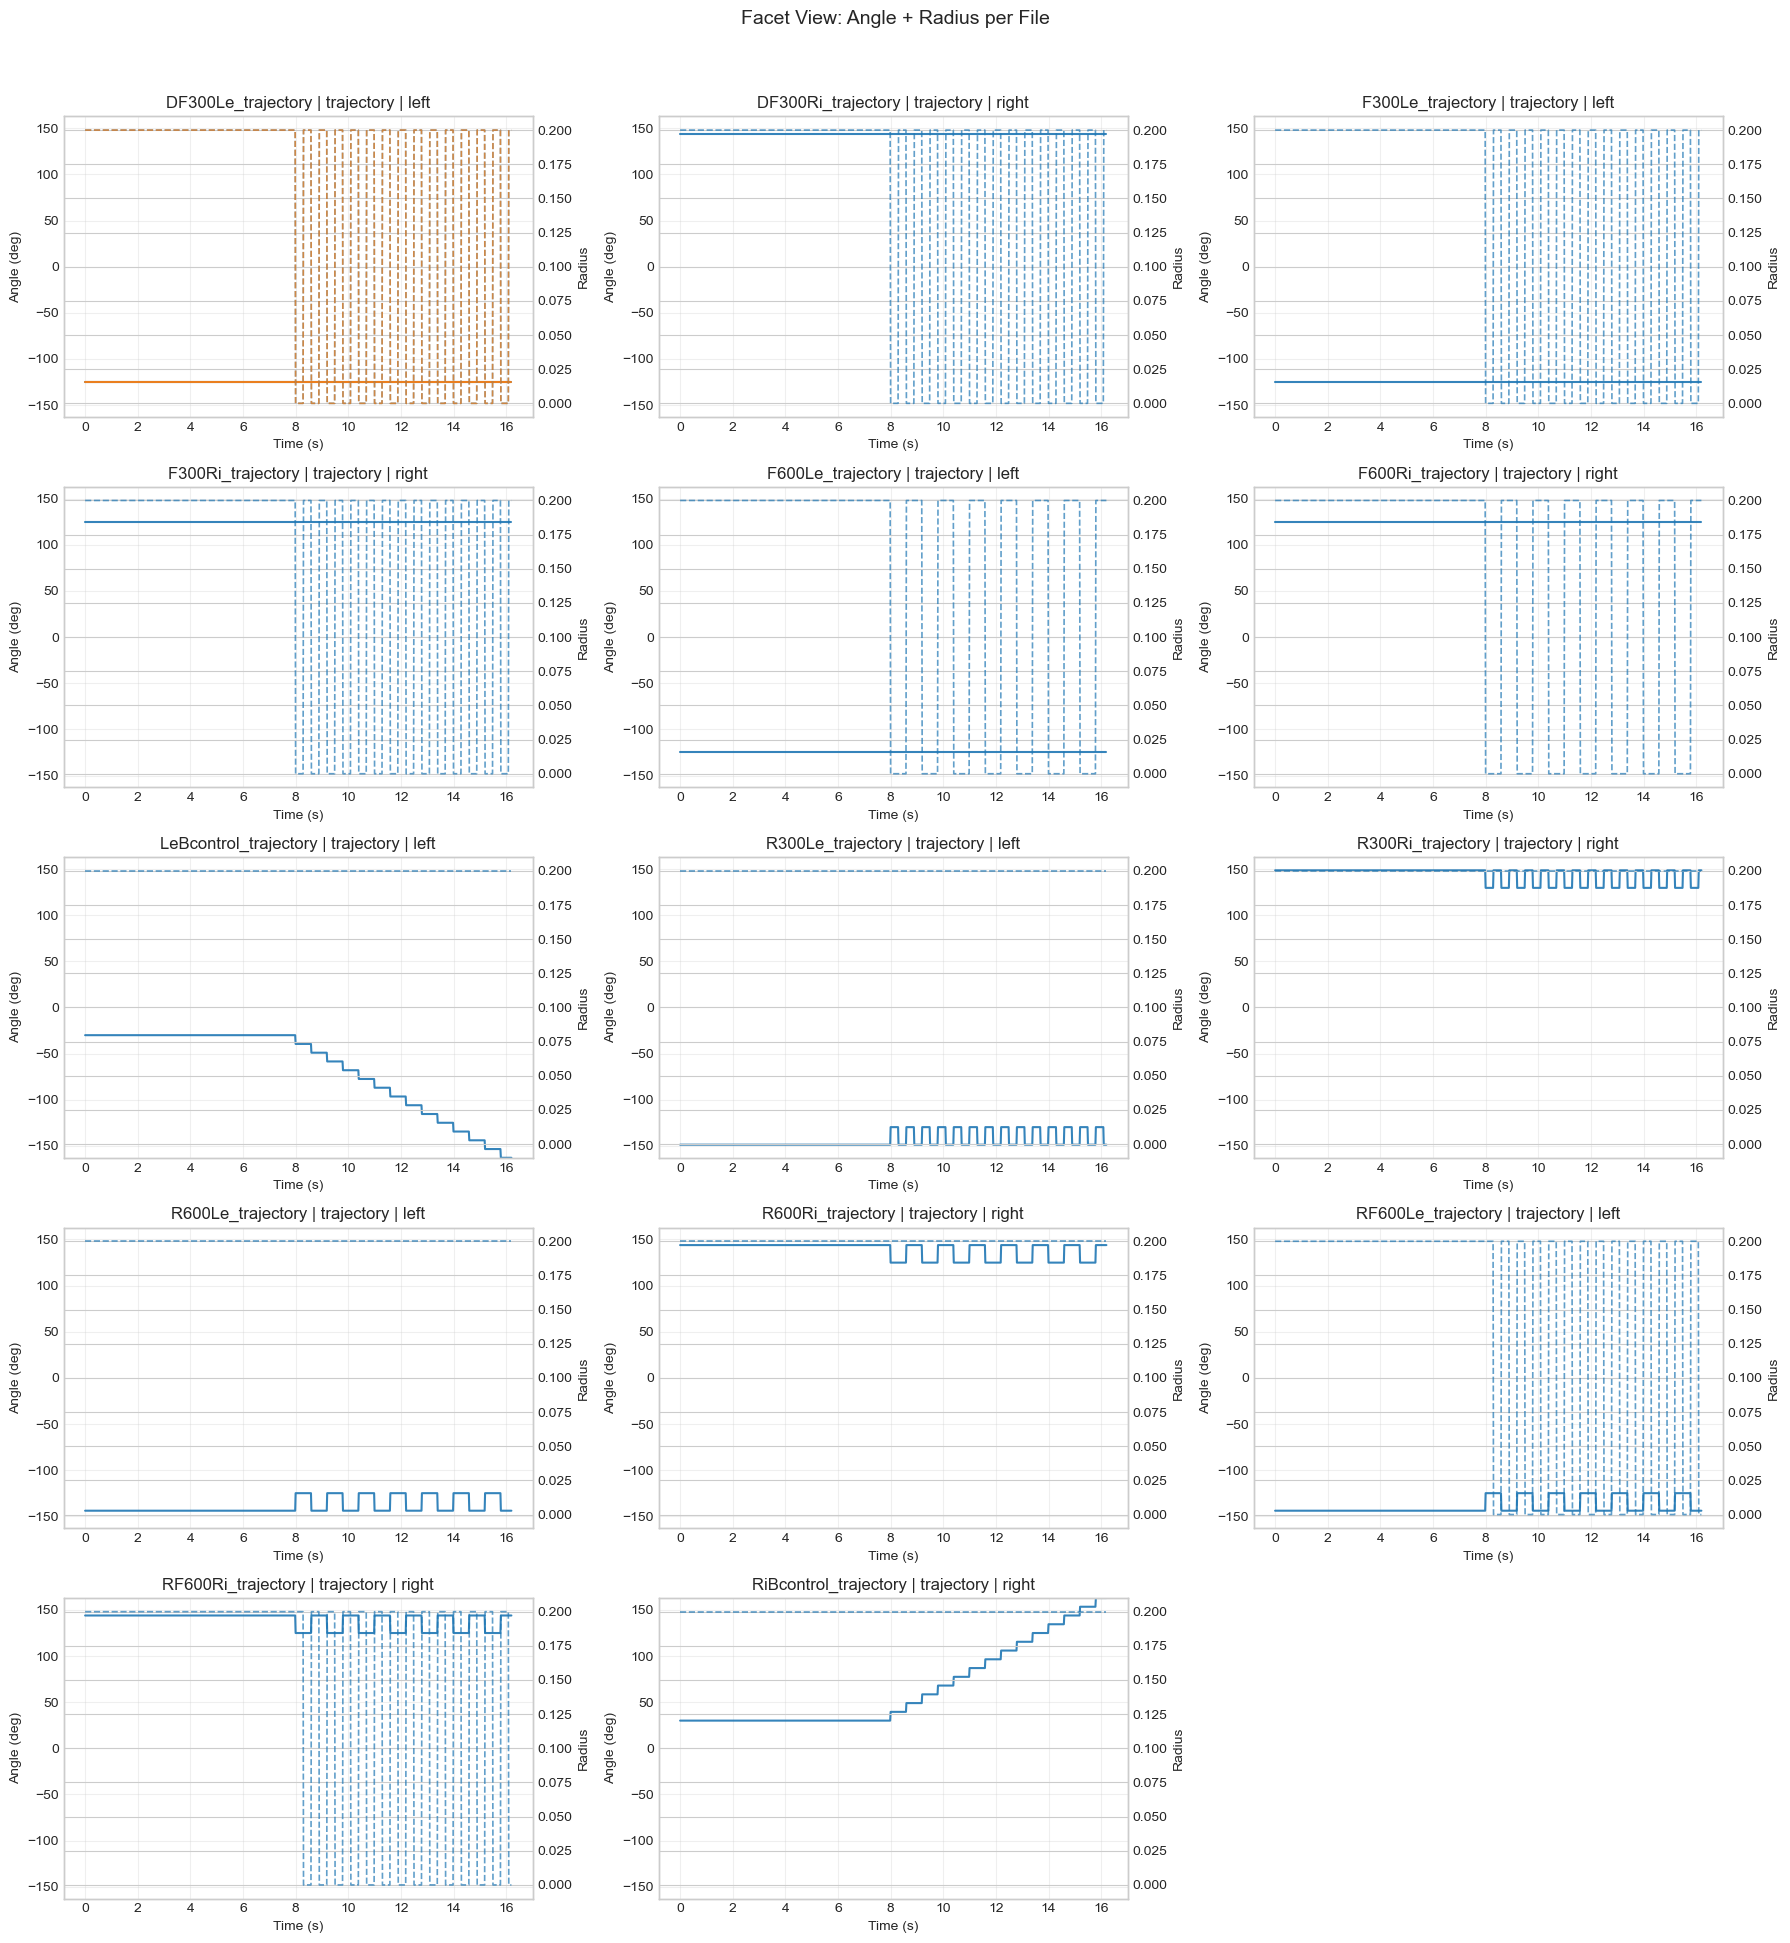

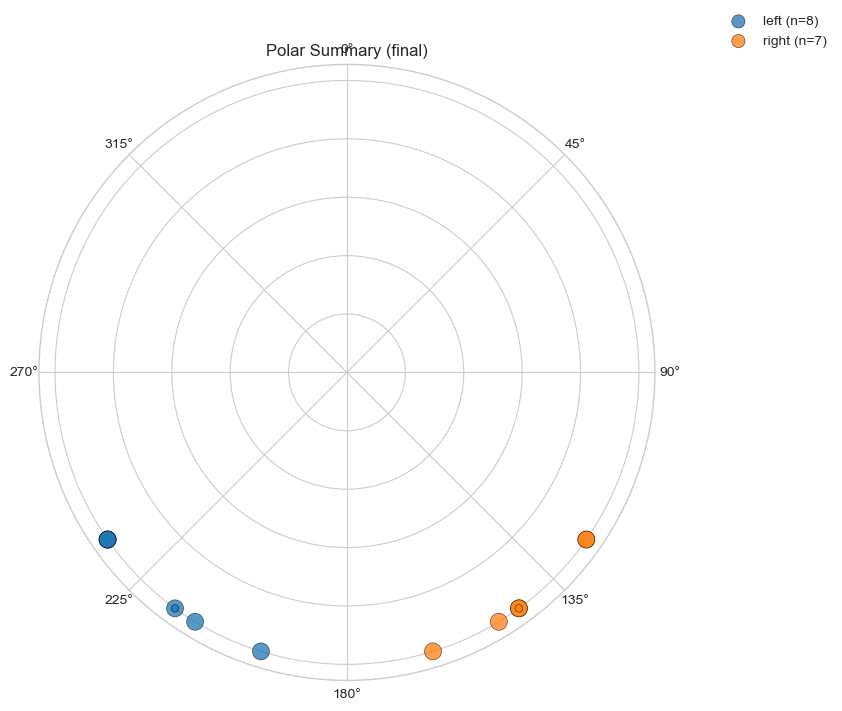

In [6]:
# -----------------------------
# Full run
# -----------------------------
if RUN_FULL:
    print(f'[FULL] files={long_df["file_id"].nunique()} rows={len(long_df)}')
    display(
        long_df[['file_id', 'stim_type', 'left_right']]
        .drop_duplicates()
        .sort_values(['stim_type', 'left_right', 'file_id'])
    )
    display(pd.crosstab(long_df['stim_type'], long_df['left_right']))

    _ = plot_facet_angle_radius(long_df, cols=facet_cols, title='Facet View: Angle + Radius per File')
    _ = plot_polar_summary(long_df, mode=polar_mode)


In [7]:
# -----------------------------
# Final summary: unique transformed angles per stimuli
# -----------------------------
if 'long_df' not in globals() or long_df.empty:
    print('No data available for angle summary.')
else:
    # Base rows with transformed angles used in plots
    angle_rows = long_df.dropna(subset=['angle_deg']).copy()

    # Unique angle list per stimulus file and dot
    unique_angles_per_stimulus = (
        angle_rows
        .groupby(['file_id', 'stim_type', 'left_right', 'dot_id'], as_index=False)
        .agg(
            unique_angles_deg=('angle_deg', lambda s: sorted(np.unique(np.round(s.to_numpy(), 6)).tolist())),
            n_unique_angles=('angle_deg', lambda s: int(np.unique(np.round(s.to_numpy(), 6)).size)),
            n_frames=('frame', 'nunique'),
        )
        .sort_values(['stim_type', 'left_right', 'file_id', 'dot_id'])
    )

    # Optional compact view by stimulus file (across dots)
    unique_angles_per_file = (
        angle_rows
        .groupby(['file_id', 'stim_type', 'left_right'], as_index=False)
        .agg(
            unique_angles_deg=('angle_deg', lambda s: sorted(np.unique(np.round(s.to_numpy(), 6)).tolist())),
            n_unique_angles=('angle_deg', lambda s: int(np.unique(np.round(s.to_numpy(), 6)).size)),
            n_dots=('dot_id', 'nunique'),
        )
        .sort_values(['stim_type', 'left_right', 'file_id'])
    )

    print('Unique transformed angles per stimulus (file + dot):')
    display(unique_angles_per_stimulus)

    print('Unique transformed angles per stimulus file (all dots merged):')
    display(unique_angles_per_file)


Unique transformed angles per stimulus (file + dot):


,file_id,stim_type,left_right,dot_id,unique_angles_deg,n_unique_angles,n_frames
0,DF300Le_trajectory,trajectory,left,dot0,[-124.920008],1,973
1,DF300Le_trajectory,trajectory,left,dot1,[-124.920008],1,973
3,F300Le_trajectory,trajectory,left,dot0,[-124.920008],1,973
5,F600Le_trajectory,trajectory,left,dot0,[-124.920008],1,973
7,LeBcontrol_trajectory,trajectory,left,dot0,"[-162.860857, -153.394685, -143.91801, -134.42...",15,973
8,R300Le_trajectory,trajectory,left,dot0,"[-148.657932, -129.647145]",2,973
10,R600Le_trajectory,trajectory,left,dot0,"[-143.91801, -124.920099]",2,973
12,RF600Le_trajectory,trajectory,left,dot0,"[-143.91801, -124.920099]",2,973
2,DF300Ri_trajectory,trajectory,right,dot0,[143.90401],1,973
4,F300Ri_trajectory,trajectory,right,dot0,[124.920008],1,973


Unique transformed angles per stimulus file (all dots merged):


,file_id,stim_type,left_right,unique_angles_deg,n_unique_angles,n_dots
0,DF300Le_trajectory,trajectory,left,[-124.920008],1,2
2,F300Le_trajectory,trajectory,left,[-124.920008],1,1
4,F600Le_trajectory,trajectory,left,[-124.920008],1,1
6,LeBcontrol_trajectory,trajectory,left,"[-162.860857, -153.394685, -143.91801, -134.42...",15,1
7,R300Le_trajectory,trajectory,left,"[-148.657932, -129.647145]",2,1
9,R600Le_trajectory,trajectory,left,"[-143.91801, -124.920099]",2,1
11,RF600Le_trajectory,trajectory,left,"[-143.91801, -124.920099]",2,1
1,DF300Ri_trajectory,trajectory,right,[143.90401],1,1
3,F300Ri_trajectory,trajectory,right,[124.920008],1,1
5,F600Ri_trajectory,trajectory,right,[124.920008],1,1
